# 02 URL Feature Analysis

This notebook compares phishing and legitimate records using only features that appear related to URL text. It does not open, visit, request, or otherwise connect to any URL.

## 1. Imports and Data Loading

We load the local CSV and define the class names used throughout the notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\singh\\AppData\\Local\\matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_FILE = PROJECT_ROOT / "data" / "raw" / "phiusil_raw.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW_DATA_FILE)
label_names = {0: "Phishing", 1: "Legitimate"}
df["class_name"] = df["label"].map(label_names)

df.shape

(235795, 56)

## 2. URL-Text-Related Columns Used Here

The following columns are selected because their names indicate URL string, domain, TLD, or URL character-count information. Webpage/content fields such as page title, forms, images, CSS, JavaScript, redirects, and references are intentionally excluded.

In [3]:
url_text_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
]

available_url_text_features = [column for column in url_text_features if column in df.columns]
available_url_text_features

['URLLength',
 'DomainLength',
 'IsDomainIP',
 'TLDLength',
 'NoOfSubDomain',
 'HasObfuscation',
 'NoOfObfuscatedChar',
 'ObfuscationRatio',
 'NoOfLettersInURL',
 'LetterRatioInURL',
 'NoOfDegitsInURL',
 'DegitRatioInURL',
 'NoOfEqualsInURL',
 'NoOfQMarkInURL',
 'NoOfAmpersandInURL',
 'NoOfOtherSpecialCharsInURL',
 'SpacialCharRatioInURL',
 'IsHTTPS']

## 3. Summary Statistics by Class

These descriptive statistics show how URL-text properties differ between phishing and legitimate records.

In [4]:
summary_by_class = df.groupby("class_name")[available_url_text_features].agg(["mean", "median", "std"])
summary_by_class.round(3)

URLLength                DomainLength                IsDomainIP  \
                mean median     std         mean median     std       mean   
class_name                                                                   
Legitimate    26.229   26.0   4.816       19.229   19.0   4.816      0.000   
Phishing      45.720   34.0  61.146       24.465   22.0  12.204      0.006   

                         TLDLength  ... NoOfAmpersandInURL  \
           median    std      mean  ...                std   
class_name                          ...                      
Legitimate    0.0  0.000     2.723  ...              0.000   
Phishing      0.0  0.079     2.819  ...              1.278   

           NoOfOtherSpecialCharsInURL               SpacialCharRatioInURL  \
                                 mean median    std                  mean   
class_name                                                                  
Legitimate                      1.245    1.0  0.504                 0.048   
Phishing                        3.803    3.0  4.998                 0.083   

                         IsHTTPS              
           median    std    mean median  std  
class_name                                    
Legitimate  0.042  0.019   1.000    1.0  0.0  
Phishing    0.080  0.036   0.492    0.0  0.5  

[2 rows x 54 columns]

## 4. Mean and Median Comparison

This table focuses on mean and median values, which are easier to compare than the full summary table.

In [5]:
means = df.groupby("class_name")[available_url_text_features].mean().T
medians = df.groupby("class_name")[available_url_text_features].median().T

mean_median_comparison = pd.concat(
    [means.add_suffix(" mean"), medians.add_suffix(" median")],
    axis=1,
).round(3)
mean_median_comparison

class_name,Legitimate mean,Phishing mean,Legitimate median,Phishing median
URLLength,26.229,45.720,26.000,34.000
DomainLength,19.229,24.465,19.000,22.000
IsDomainIP,0.000,0.006,0.000,0.000
TLDLength,2.723,2.819,3.000,3.000
NoOfSubDomain,1.162,1.169,1.000,1.000
HasObfuscation,0.000,0.005,0.000,0.000
NoOfObfuscatedChar,0.000,0.058,0.000,0.000
ObfuscationRatio,0.000,0.000,0.000,0.000
NoOfLettersInURL,12.933,28.107,13.000,20.000
LetterRatioInURL,0.477,0.568,0.480,0.577


The strongest early differences are useful EDA clues, but they are not final feature-selection decisions yet. Later steps should verify that each selected feature can be recreated from a submitted URL string.

## 5. URL Length Distribution

URL length is a common phishing signal because some suspicious URLs are unusually long or complex.

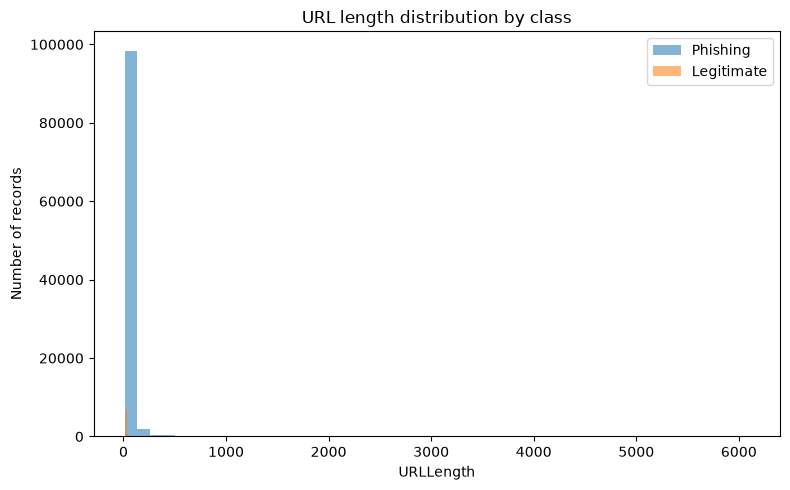

WindowsPath('D:/Projects/phishing-url-detection/reports/figures/url_length_distribution.png')

In [6]:
plt.figure(figsize=(8, 5))
for label, class_name in label_names.items():
    values = df.loc[df["label"] == label, "URLLength"]
    plt.hist(values, bins=50, alpha=0.55, label=class_name)

plt.title("URL length distribution by class")
plt.xlabel("URLLength")
plt.ylabel("Number of records")
plt.legend()
plt.tight_layout()
url_length_path = FIGURES_DIR / "url_length_distribution.png"
plt.savefig(url_length_path, dpi=150)
plt.show()

url_length_path

Interpretation: this chart compares how URL lengths are spread for both classes. Large separation would make URL length a useful candidate feature.

## 6. Domain Length Distribution

Domain length is another safely extractable property from URL text.

<Figure size 800x500 with 0 Axes>

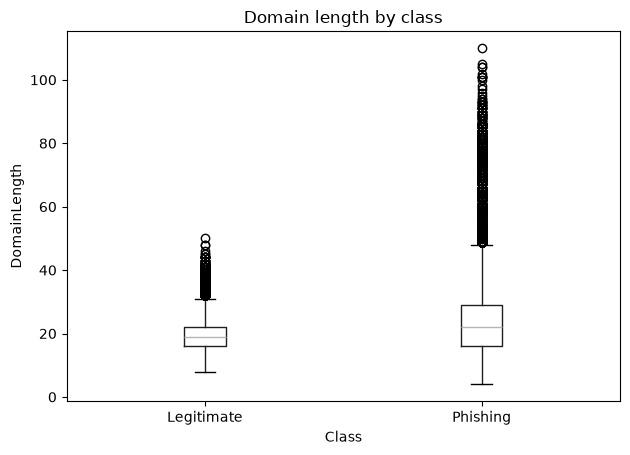

WindowsPath('D:/Projects/phishing-url-detection/reports/figures/domain_length_by_class.png')

In [7]:
plt.figure(figsize=(8, 5))
df.boxplot(column="DomainLength", by="class_name", grid=False)
plt.title("Domain length by class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("DomainLength")
plt.tight_layout()
domain_length_path = FIGURES_DIR / "domain_length_by_class.png"
plt.savefig(domain_length_path, dpi=150)
plt.show()

domain_length_path

Interpretation: the boxplot shows the median, spread, and outliers for domain length in each class.

## 7. Character Count Comparison

Counts of digits, letters, and special characters can describe URL complexity without visiting the website.

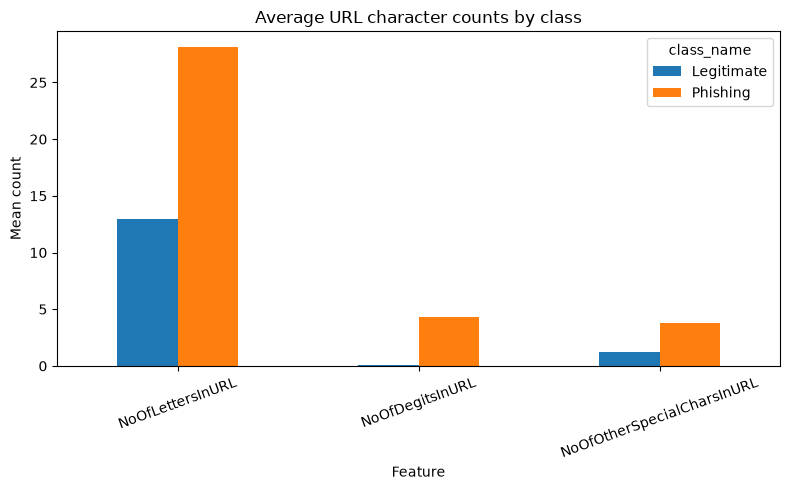

class_name,Legitimate,Phishing
NoOfLettersInURL,12.933,28.107
NoOfDegitsInURL,0.051,4.326
NoOfOtherSpecialCharsInURL,1.245,3.803


In [8]:
character_count_features = [
    "NoOfLettersInURL",
    "NoOfDegitsInURL",
    "NoOfOtherSpecialCharsInURL",
]
character_means = df.groupby("class_name")[character_count_features].mean().T

ax = character_means.plot(kind="bar", figsize=(8, 5), rot=20)
ax.set_title("Average URL character counts by class")
ax.set_xlabel("Feature")
ax.set_ylabel("Mean count")
plt.tight_layout()
character_counts_path = FIGURES_DIR / "character_counts_by_class.png"
plt.savefig(character_counts_path, dpi=150)
plt.show()

character_means.round(3)

Interpretation: this chart compares average URL character composition. Differences in digit or special-character counts may help the Decision Tree split URLs later.

## 8. Subdomain and HTTPS Text Indicators

Subdomain count and HTTPS text can both be extracted from the URL string.

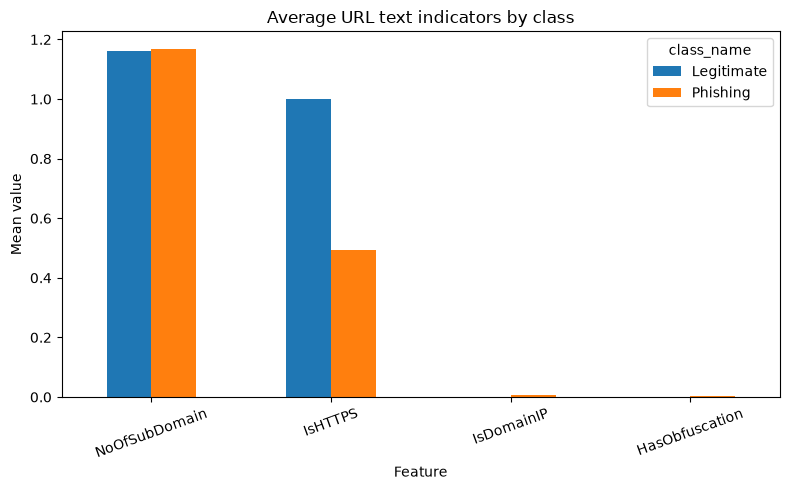

class_name,Legitimate,Phishing
NoOfSubDomain,1.162,1.169
IsHTTPS,1.000,0.492
IsDomainIP,0.000,0.006
HasObfuscation,0.000,0.005


In [9]:
indicator_features = ["NoOfSubDomain", "IsHTTPS", "IsDomainIP", "HasObfuscation"]
indicator_means = df.groupby("class_name")[indicator_features].mean().T

ax = indicator_means.plot(kind="bar", figsize=(8, 5), rot=20)
ax.set_title("Average URL text indicators by class")
ax.set_xlabel("Feature")
ax.set_ylabel("Mean value")
plt.tight_layout()
indicator_path = FIGURES_DIR / "url_text_indicators_by_class.png"
plt.savefig(indicator_path, dpi=150)
plt.show()

indicator_means.round(3)

Interpretation: binary indicators are shown as averages, so values closer to 1 mean the property appears more often in that class.

## Preliminary URL-Only Feature Candidates

Based on this early URL-only exploration, these features appear promising for the final safe model:

- `URLLength`
- `DomainLength`
- `TLDLength`
- `NoOfSubDomain`
- `IsDomainIP`
- `IsHTTPS`
- `HasObfuscation`
- `NoOfObfuscatedChar`
- `ObfuscationRatio`
- `NoOfLettersInURL`
- `LetterRatioInURL`
- `NoOfDegitsInURL`
- `DegitRatioInURL`
- `NoOfEqualsInURL`
- `NoOfQMarkInURL`
- `NoOfAmpersandInURL`
- `NoOfOtherSpecialCharsInURL`
- `SpacialCharRatioInURL`

This is not the final model feature set. Later work should verify definitions, recreate the selected features from raw URL text, and exclude any feature that depends on webpage access.